Second RNN GridWorld Experiment
Goal: Increase the number of trajectories (batches) used for training in the RNN

Results observation: the increase of trajectories in the training set seems to have equalled the field between the MLP and the RNN, providing similar training and validation loss for both architectures. Interestingly, manipulating the action probabilities to favor turning over forward movement or stopping seems to have widen the gap between them. This is not surprising, since turning changes the observation environment significantly more than forward movement does.

In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Imports

In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

import functions.trajectories as trajectories
import functions.NN_models as NN_models
import functions.gridworld as gridworld
import functions.model_training_evaluator as model_training_evaluator
import functions.dataset_generator as dataset_generator
import numpy as np
import pandas as pd
import torch
from torch import nn
import matplotlib.pyplot as plt

print(sys.executable)
print(torch.__version__)

/home/seblee/miniconda3/envs/main/bin/python
2.14.0+cu130


State variables

In [3]:

HEIGHT = 29
WIDTH = 36
VIEW_SIZE = 5

START_X = 7
START_Y = 7
START_DIRECTION = 2

N_STEPS = 500
N_TRAJ = 20

ACTION_PROBS = [0.6, 0.15, 0.15, 0.1]
ACTION_PROBS_TURN_HEAVY = [0.3, 0.35, 0.35, 0.0]

SEED = 42
TRAINER_MOVE_SEED = 100
TRAINER_START_SEED = 150
VALIDATOR_MOVE_SEED = 300
VALIDATOR_START_SEED = 350

TEST_SEED = 123
TEST_STEPS = 200

Gridworld Creation

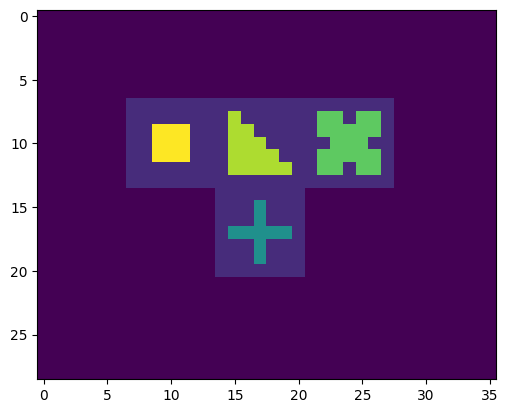

In [4]:
grid = gridworld.GridWorld(HEIGHT, WIDTH)
grid.add_rectangle_region(7, 14, 7, 28)
grid.add_rectangle_region(14, 21, 14, 21)
grid.add_square_shape(9, 9, 3, 7)
grid.add_triangle_shape(8, 15, 5, 0, 6)
grid.add_square_shape(9, 23, 3, 5)
grid.add_square_shape(8, 22, 2, 5)
grid.add_square_shape(11, 22, 2, 5)
grid.add_square_shape(11, 25, 2, 5)
grid.add_square_shape(8, 25, 2, 5)
grid.add_rectangle_shape(15, 17, 5, 1, 3)
grid.add_rectangle_shape(17, 15, 1, 5, 3)
plt.imshow(grid.grid)


NN Training and Validation

Trainer error: 1.2201591730117798
Validator error: 1.360748291015625


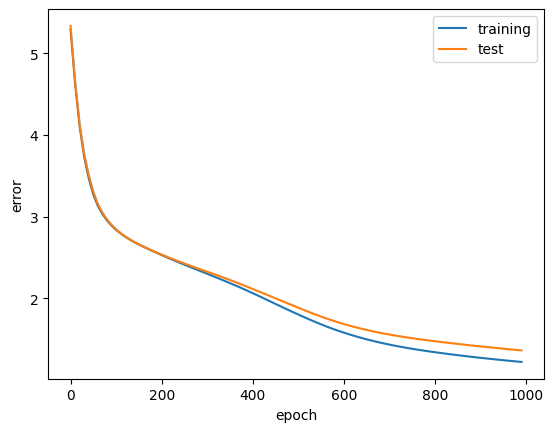

Trainer error: 1.1916706562042236
Validator error: 1.368551254272461


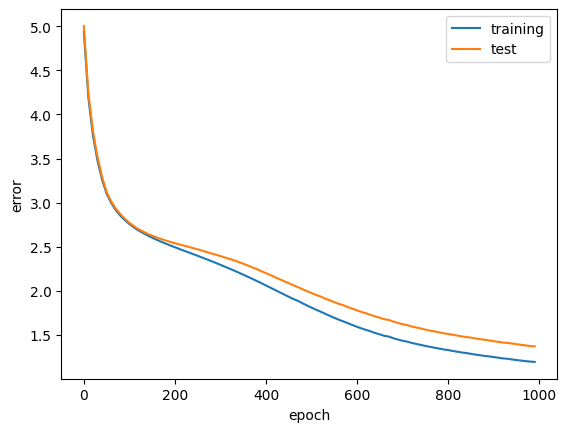

Baseline loss:  4.676159858703613
Baseline loss:  4.676159858703613


In [5]:
trainer_inputs_stack, trainer_target_stack, trainer_agent_list = dataset_generator.generate_dataset(grid, trajectories.random_policy, ACTION_PROBS, VIEW_SIZE, N_STEPS, N_TRAJ, TRAINER_MOVE_SEED, random_start=True, start_seed_start=TRAINER_START_SEED)
validator_inputs_stack, validator_target_stack, validator_agent_list = dataset_generator.generate_dataset(grid, trajectories.random_policy, ACTION_PROBS, VIEW_SIZE, N_STEPS, 5, VALIDATOR_MOVE_SEED, random_start=True, start_seed_start=VALIDATOR_START_SEED)

INPUT_SIZE = trainer_inputs_stack.shape[2]
OUTPUT_SIZE = trainer_target_stack.shape[2]
HIDDEN_SIZE = 64     

model_MLP = NN_models.SimpleMLP(INPUT_SIZE, OUTPUT_SIZE, HIDDEN_SIZE, "relu")
loss_history = model_training_evaluator.model_training(model_MLP, trainer_inputs_stack, trainer_target_stack, validator_inputs_stack, validator_target_stack)


model_training_evaluator.model_evaluation(model_MLP, trainer_inputs_stack, trainer_target_stack, "trainer")
model_training_evaluator.model_evaluation(model_MLP, validator_inputs_stack, validator_target_stack, "validator")


model_RNN = NN_models.BasicRNN(INPUT_SIZE, OUTPUT_SIZE, HIDDEN_SIZE, "relu")
loss_history = model_training_evaluator.model_training(model_RNN, trainer_inputs_stack, trainer_target_stack, validator_inputs_stack, validator_target_stack)


model_training_evaluator.model_evaluation(model_RNN, trainer_inputs_stack, trainer_target_stack, "trainer")
model_training_evaluator.model_evaluation(model_RNN, validator_inputs_stack, validator_target_stack, "validator")
model_training_evaluator.baseline_evaluation(validator_inputs_stack, validator_target_stack)

model_training_evaluator.baseline_evaluation(validator_inputs_stack, validator_target_stack)



Turn-Heavy Trajectory run

Trainer error: 1.954479694366455
Validator error: 2.010129690170288


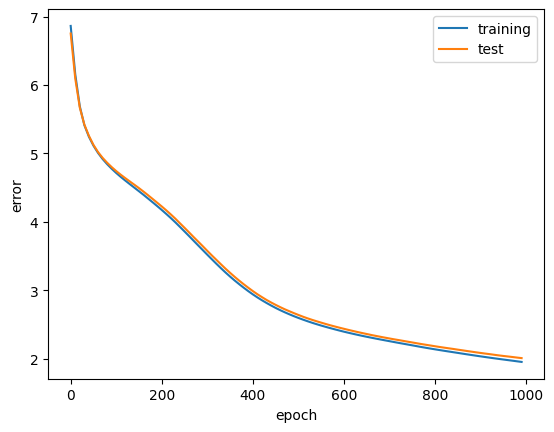

Trainer error: 1.6905878782272339
Validator error: 1.8476250171661377


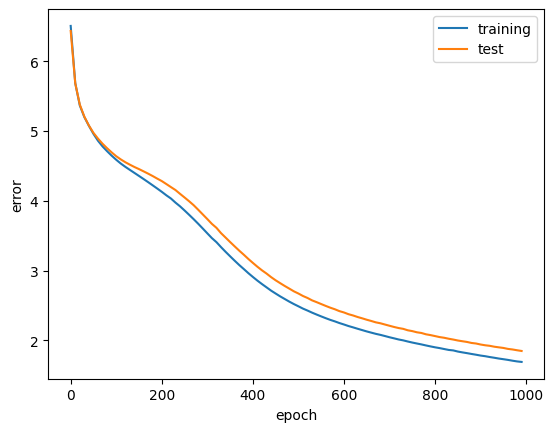

Baseline loss:  9.019743919372559
Baseline loss:  9.019743919372559


In [6]:
trainer_inputs_stack_turn_heavy, trainer_target_stack_turn_heavy, trainer_agent_list_turn_heavy = dataset_generator.generate_dataset(grid, trajectories.random_policy, ACTION_PROBS_TURN_HEAVY, VIEW_SIZE, N_STEPS, N_TRAJ, TRAINER_MOVE_SEED, random_start=True, start_seed_start=TRAINER_START_SEED)

validator_inputs_stack_turn_heavy, validator_target_stack_turn_heavy, validator_agent_list_turn_heavy = dataset_generator.generate_dataset(grid, trajectories.random_policy, ACTION_PROBS_TURN_HEAVY, VIEW_SIZE, N_STEPS, 5, VALIDATOR_MOVE_SEED, random_start=True, start_seed_start=VALIDATOR_START_SEED)

INPUT_SIZE_TURN_HEAVY = trainer_inputs_stack_turn_heavy.shape[2]

OUTPUT_SIZE_TURN_HEAVY = trainer_target_stack_turn_heavy.shape[2]

HIDDEN_SIZE_TURN_HEAVY = 64     

model_MLP_turn_heavy = NN_models.SimpleMLP(INPUT_SIZE_TURN_HEAVY, OUTPUT_SIZE_TURN_HEAVY, HIDDEN_SIZE_TURN_HEAVY, "relu")

loss_history_turn_heavy = model_training_evaluator.model_training(model_MLP_turn_heavy, trainer_inputs_stack_turn_heavy, trainer_target_stack_turn_heavy, validator_inputs_stack_turn_heavy, validator_target_stack_turn_heavy)


model_training_evaluator.model_evaluation(model_MLP_turn_heavy, trainer_inputs_stack_turn_heavy, trainer_target_stack_turn_heavy, "trainer")

model_training_evaluator.model_evaluation(model_MLP_turn_heavy, validator_inputs_stack_turn_heavy, validator_target_stack_turn_heavy, "validator")


model_RNN_turn_heavy = NN_models.BasicRNN(INPUT_SIZE_TURN_HEAVY, OUTPUT_SIZE_TURN_HEAVY, HIDDEN_SIZE_TURN_HEAVY, "relu")

loss_history_turn_heavy = model_training_evaluator.model_training(model_RNN_turn_heavy, trainer_inputs_stack_turn_heavy, trainer_target_stack_turn_heavy, validator_inputs_stack_turn_heavy, validator_target_stack_turn_heavy)


model_training_evaluator.model_evaluation(model_RNN_turn_heavy, trainer_inputs_stack_turn_heavy, trainer_target_stack_turn_heavy, "trainer")

model_training_evaluator.model_evaluation(model_RNN_turn_heavy, validator_inputs_stack_turn_heavy, validator_target_stack_turn_heavy, "validator")

model_training_evaluator.baseline_evaluation(validator_inputs_stack_turn_heavy, validator_target_stack_turn_heavy)

model_training_evaluator.baseline_evaluation(validator_inputs_stack_turn_heavy, validator_target_stack_turn_heavy)

Validator Error per Action Type

In [12]:
results_array = []

trainer_RNN, trainer_RNN_action_losses = model_training_evaluator.evaluator_per_action(model_RNN, trainer_inputs_stack, trainer_target_stack, "trainer, RNN")
validator_RNN, validator_RNN_action_losses = model_training_evaluator.evaluator_per_action(model_RNN, validator_inputs_stack, validator_target_stack, "validator, RNN")

trainer_MLP, trainer_MLP_action_losses = model_training_evaluator.evaluator_per_action(model_MLP, trainer_inputs_stack, trainer_target_stack, "trainer, MLP")
validator_MLP, validator_MLP_action_losses = model_training_evaluator.evaluator_per_action(model_MLP, validator_inputs_stack, validator_target_stack, "validator, MLP")

results_array.append(trainer_RNN_action_losses)
results_array.append(trainer_MLP_action_losses)
results_array.append(validator_RNN_action_losses)
results_array.append(validator_MLP_action_losses)

results = pd.DataFrame(
    results_array,
    index = [trainer_RNN, trainer_MLP, validator_RNN, validator_MLP],
    columns = ["Forward", "Left", "Right", "Stop"]
)

results

,Forward,Left,Right,Stop
"trainer, RNN",0.494267,2.479250,2.395413,1.568714
"trainer, MLP",0.416464,2.769058,2.684557,1.464258
"validator, RNN",0.609717,2.776272,2.953401,1.809099
"validator, MLP",0.499417,3.117160,3.186613,1.607227
